# Sabotage scaling law: analysis notebook

Reproduces the paper statistics from the scientifically named result directories and model-specific question-selection buckets in `experimental_files/`.

Sections: (1) load and pool the runs, (2) win rate and honest defection by adversarial fraction, (3) trend and size tests, (4) count versus share head to head, (5) robustness battery, (6) coordination arms, (7) charts.

Dependencies: numpy, pandas, scipy, matplotlib. No statsmodels (a plain logit GLM is implemented below).

In [1]:
import os
while not os.path.isdir("experimental_files") and os.getcwd() != "/": os.chdir("..")   # run from the repo root
print("working directory:", os.getcwd())

import csv, numpy as np, pandas as pd
from scipy import stats
from scipy.optimize import minimize
from scipy.special import expit
import matplotlib.pyplot as plt
rng = np.random.default_rng(0)

FAMILIES = [  # name, runs, probe selection with buckets
    ("Gemini 3.8 Flash", ["experimental_files/results/main_grid/gemini-3.8-flash/honest_agents_2", "experimental_files/results/main_grid/gemini-3.8-flash/honest_agents_4", "experimental_files/results/main_grid/gemini-3.8-flash/honest_agents_8", "experimental_files/results/main_grid/gemini-3.8-flash/honest_agents_12"], "experimental_files/question_selection/gemini-3.8-flash/selection.csv"),
    ("Grok 4.3", ["experimental_files/results/main_grid/grok-4.3"], "experimental_files/question_selection/grok-4.3/selection.csv"),
    ("DeepSeek V4.1 Flash", ["experimental_files/results/main_grid/deepseek-v4.1-flash"], "experimental_files/question_selection/deepseek-v4.1-flash/selection.csv"),
    ("Muse Glimmer 30B", ["experimental_files/results/main_grid/muse-glimmer-30b"], "experimental_files/question_selection/muse-glimmer-30b/selection.csv"),
]
COORD = {"Gemini 3.8 Flash": ["experimental_files/results/coordinated_deceivers/gemini-3.8-flash"], "Grok 4.3": ["experimental_files/results/coordinated_deceivers/grok-4.3"]}

def load(runs, bucket_file):
    b = {r["id"]: r["correct_of_k"] for r in csv.DictReader(open(bucket_file))}
    rows = []
    for t in runs:
        for r in csv.DictReader(open(f"{t}/per_game.csv")):
            if b.get(r["question_id"]) is None: continue
            N, k = int(r["N"]), int(r["k"])
            rows.append(dict(question=r["question_id"], N=N, k=k, honest=N-k, cfg=f"{N-k}+{k}", ratio=round(k/N, 2),
                             bucket=b[r["question_id"]], win=int(r["group_win"] == "1"),
                             flips=int(r["n_switched"]), r0_right=round(float(r["honest_r0_acc"]) * int(r["n_honest"]))))
    return pd.DataFrame(rows)

data = {name: load(runs, bf) for name, runs, bf in FAMILIES}
coord = {name: load(runs, dict(FAMILIES)[name] if False else next(bf for n, _, bf in FAMILIES if n == name)) for name, runs in COORD.items()}
for n, d in data.items(): print(f"{n:<22} {len(d):5d} games, {d.question.nunique():3d} questions")
for n, d in coord.items(): print(f"{n+' coordinated':<22} {len(d):5d} games")

working directory: .
Gemini 3.8 Flash        1284 games, 107 questions
Grok 4.3                1140 games,  95 questions
DeepSeek V4.1 Flash     1140 games,  95 questions
Muse Glimmer 30B         612 games,  51 questions
Gemini 3.8 Flash coordinated   963 games
Grok 4.3 coordinated     852 games


## 2. Win rate and honest defection by adversarial fraction

Win = the correct answer holds a strict majority of all final votes. Defection = honest agents right at round 0 who voted wrong, as a share of those right at round 0.

In [2]:
RATIOS = [(0.0, "2+0,4+0,8+0"), (0.2, "8+2,12+3"), (0.33, "2+1,4+2,8+4,12+6"), (0.43, "4+3,8+6,12+9")]
def by_ratio(d):
    out = []
    for r, cfgs in RATIOS:
        s = d[np.isclose(d.ratio, r)]
        out.append(dict(ratio=r, configs=cfgs, games=len(s), win=100*s.win.mean(), defection=100*s.flips.sum()/s.r0_right.sum()))
    return pd.DataFrame(out)
summary = pd.concat({n: by_ratio(d) for n, d in data.items()}, names=["family"]).reset_index(level=0)
summary.pivot(index="ratio", columns="family", values=["win", "defection"]).round(0)

win                                             \
family DeepSeek V4.1 Flash Gemini 3.8 Flash Grok 4.3 Muse Glimmer 30B   
ratio                                                                   
0.00                  52.0             64.0     54.0             50.0   
0.20                  51.0             62.0     50.0             41.0   
0.33                  47.0             53.0     43.0             32.0   
0.43                  39.0             46.0     37.0             20.0   

                 defection                                             
family DeepSeek V4.1 Flash Gemini 3.8 Flash Grok 4.3 Muse Glimmer 30B  
ratio                                                                  
0.00                  26.0             13.0     14.0             20.0  
0.20                  31.0             21.0     26.0             37.0  
0.33                  31.0             28.0     27.0             45.0  
0.43                  36.0             36.0     35.0             55.0

In [3]:
# full grid: win rate by configuration and bucket, one table per family
CFGS = ["2+0","2+1","4+0","4+2","4+3","8+0","8+2","8+4","8+6","12+3","12+6","12+9"]
def grid(d):
    t = d.pivot_table(index="bucket", columns="cfg", values="win", aggfunc="mean").reindex(columns=CFGS) * 100
    t.loc["All"] = d.groupby("cfg").win.mean().reindex(CFGS) * 100
    t.loc["defection"] = [100*g.flips.sum()/g.r0_right.sum() for _, g in d.groupby("cfg")] if False else d.groupby("cfg").apply(lambda g: 100*g.flips.sum()/g.r0_right.sum()).reindex(CFGS)
    return t.round(0)
for n, d in data.items():
    print(f"\n{n}"); display(grid(d))


Gemini 3.8 Flash


cfg,2+0,2+1,4+0,4+2,4+3,8+0,8+2,8+4,8+6,12+3,12+6,12+9
bucket,,,,,,,,,,,,
1,55.0,36.0,38.0,38.0,29.0,62.0,43.0,36.0,31.0,50.0,40.0,38.0
2,53.0,50.0,50.0,47.0,47.0,77.0,60.0,50.0,47.0,60.0,60.0,50.0
3,83.0,69.0,86.0,69.0,60.0,83.0,83.0,71.0,63.0,80.0,77.0,63.0
All,64.0,50.0,57.0,50.0,44.0,73.0,61.0,51.0,46.0,63.0,58.0,50.0
defection,12.0,15.0,16.0,28.0,37.0,13.0,20.0,31.0,37.0,22.0,29.0,35.0



Grok 4.3


cfg,2+0,2+1,4+0,4+2,4+3,8+0,8+2,8+4,8+6,12+3,12+6,12+9
bucket,,,,,,,,,,,,
1,37.0,21.0,32.0,18.0,18.0,45.0,26.0,26.0,21.0,29.0,24.0,21.0
2,40.0,40.0,57.0,43.0,40.0,60.0,57.0,47.0,30.0,53.0,43.0,47.0
3,74.0,74.0,85.0,74.0,67.0,74.0,81.0,74.0,44.0,70.0,67.0,67.0
All,48.0,42.0,55.0,42.0,39.0,58.0,52.0,46.0,31.0,48.0,42.0,42.0
defection,6.0,11.0,13.0,23.0,29.0,17.0,24.0,29.0,42.0,28.0,29.0,32.0



DeepSeek V4.1 Flash


cfg,2+0,2+1,4+0,4+2,4+3,8+0,8+2,8+4,8+6,12+3,12+6,12+9
bucket,,,,,,,,,,,,
1,24.0,24.0,42.0,21.0,24.0,34.0,24.0,26.0,26.0,29.0,21.0,18.0
2,57.0,67.0,60.0,53.0,50.0,67.0,63.0,60.0,40.0,67.0,53.0,43.0
3,67.0,78.0,78.0,70.0,63.0,63.0,67.0,52.0,52.0,70.0,70.0,56.0
All,46.0,53.0,58.0,45.0,43.0,53.0,48.0,44.0,38.0,53.0,45.0,37.0
defection,18.0,23.0,24.0,26.0,27.0,28.0,28.0,38.0,34.0,33.0,29.0,41.0



Muse Glimmer 30B


cfg,2+0,2+1,4+0,4+2,4+3,8+0,8+2,8+4,8+6,12+3,12+6,12+9
bucket,,,,,,,,,,,,
1,24.0,16.0,24.0,16.0,12.0,32.0,16.0,12.0,8.0,24.0,4.0,4.0
2,50.0,69.0,56.0,31.0,31.0,81.0,44.0,44.0,12.0,56.0,25.0,25.0
3,80.0,60.0,90.0,60.0,40.0,90.0,80.0,70.0,50.0,80.0,70.0,40.0
All,43.0,41.0,47.0,29.0,24.0,59.0,37.0,33.0,18.0,45.0,24.0,18.0
defection,19.0,27.0,19.0,43.0,48.0,21.0,37.0,46.0,57.0,37.0,47.0,56.0


## 3. Trend and size tests

* Cochran–Armitage trend of win on fraction, with a permutation null that reshuffles configurations within question (games on the same question are correlated).
* Chi-square across group sizes within each fraction.
* Fisher exact on same-count pairs (4+2 vs 8+2, 4+3 vs 12+3, 8+6 vs 12+6).

In [4]:
def ca_trend(d, ycol="win", perms=2000):
    x = d.ratio.values; y = d[ycol].values.astype(float); pbar = y.mean(); xbar = x.mean()
    z = ((y-pbar)*(x-xbar)).sum() / np.sqrt(pbar*(1-pbar)*((x-xbar)**2).sum())
    idx = {q: np.where(d.question.values == q)[0] for q in d.question.unique()}
    zs = []
    for _ in range(perms):
        xp = x.copy()
        for ii in idx.values(): xp[ii] = rng.permutation(x[ii])
        zs.append(((y-pbar)*(xp-xbar)).sum() / np.sqrt(pbar*(1-pbar)*((xp-xbar)**2).sum()))
    return z, (np.sum(np.abs(zs) >= abs(z)) + 1) / (perms + 1)

def size_tests(d):
    out = []
    for r, sub in d.groupby("ratio"):
        if sub.N.nunique() < 2: continue
        tab = pd.crosstab(sub.N, sub.win); _, p, _, _ = stats.chi2_contingency(tab)
        out.append(f"{r:.2f}: " + " ".join(f"N={n} {100*w:.0f}%" for n, w in zip(tab.index, tab[1]/tab.sum(axis=1))) + f" (p={p:.2f})")
    return out

def same_count(d):
    out = []
    for k, (a, b) in ((2, ("4+2","8+2")), (3, ("4+3","12+3")), (6, ("8+6","12+6"))):
        A = d[d.cfg == a].win; B = d[d.cfg == b].win
        _, p = stats.fisher_exact([[A.sum(), len(A)-A.sum()], [B.sum(), len(B)-B.sum()]])
        out.append(f"k={k}: {a} {100*A.mean():.0f}% vs {b} {100*B.mean():.0f}% (p={p:.3f})")
    return out

for n, d in data.items():
    z, p = ca_trend(d); print(f"\n{n}: trend z={z:.2f}, clustered permutation p={p:.4f}")
    print("  size within fraction:", *size_tests(d), sep="\n    ")
    print("  same count, larger room:", *same_count(d), sep="\n    ")


Gemini 3.8 Flash: trend z=-4.89, clustered permutation p=0.0005
  size within fraction:
    0.00: N=2 64% N=4 57% N=8 73% (p=0.05)
    0.20: N=10 61% N=15 63% (p=0.89)
    0.33: N=3 50% N=6 50% N=12 51% N=18 58% (p=0.64)
    0.43: N=7 44% N=14 46% N=21 50% (p=0.70)
  same count, larger room:
    k=2: 4+2 50% vs 8+2 61% (p=0.169)
    k=3: 4+3 44% vs 12+3 63% (p=0.009)
    k=6: 8+6 46% vs 12+6 58% (p=0.100)

Grok 4.3: trend z=-4.12, clustered permutation p=0.0005
  size within fraction:
    0.00: N=2 48% N=4 55% N=8 58% (p=0.41)
    0.20: N=10 52% N=15 48% (p=0.77)
    0.33: N=3 42% N=6 42% N=12 46% N=18 42% (p=0.92)
    0.43: N=7 39% N=14 31% N=21 42% (p=0.23)
  same count, larger room:
    k=2: 4+2 42% vs 8+2 52% (p=0.245)
    k=3: 4+3 39% vs 12+3 48% (p=0.242)
    k=6: 8+6 31% vs 12+6 42% (p=0.131)

DeepSeek V4.1 Flash: trend z=-2.96, clustered permutation p=0.0005
  size within fraction:
    0.00: N=2 46% N=4 58% N=8 53% (p=0.28)
    0.20: N=10 48% N=15 53% (p=0.66)
    0.33: N=3 53

## 3b. Linearity of the win rate in the adversarial fraction

Three quantities per family: the slope of win rate on fraction (percentage points per 0.1 of the group adversarial, game-level weighted least squares, CI from a bootstrap that resamples questions), the R² of a straight line through the four fraction-level means, and the same R² for two rival shapes: a saturating square-root curve (Asch's plateau) and an any-adversary step.

In [ ]:
LEVELS = [0.0, 0.2, 0.33, 0.43]
def linearity(d, boot=500):
    fr = d.ratio.values; w = d.win.values.astype(float); qs = d.question.values
    means = np.array([100*w[np.isclose(fr, l, atol=0.02)].mean() for l in LEVELS])
    ns = np.array([np.isclose(fr, l, atol=0.02).sum() for l in LEVELS], float)
    def r2_of(col):
        Xa = np.column_stack([np.ones(4), col]); b = np.linalg.lstsq(Xa*np.sqrt(ns)[:, None], means*np.sqrt(ns), rcond=None)[0]; p = Xa @ b
        return 1 - (ns*(means-p)**2).sum() / (ns*(means-np.average(means, weights=ns))**2).sum()
    r2_lin, r2_sat, r2_step = r2_of(np.array(LEVELS)), r2_of(np.sqrt(LEVELS)), r2_of((np.array(LEVELS) > 0).astype(float))
    slope = 100*np.cov(fr, w)[0, 1]/np.var(fr)
    uq = np.unique(qs); idx = {q: np.where(qs == q)[0] for q in uq}; sl = []
    for _ in range(boot):
        ii = np.concatenate([idx[q] for q in rng.choice(uq, len(uq), replace=True)]); sl.append(100*np.cov(fr[ii], w[ii])[0, 1]/np.var(fr[ii]))
    lo, hi = np.percentile(sl, [2.5, 97.5])
    return dict(win_by_fraction="/".join(f"{m:.0f}" for m in means), slope_per_0p1=slope/10, ci_low=lo/10, ci_high=hi/10,
                r2_linear=r2_lin, r2_saturating=r2_sat, r2_step=r2_step)

lin = pd.DataFrame({n: linearity(d) for n, d in data.items()}).T
allg2 = pd.concat(data.values()); print(f"pooled slope: {100*np.cov(allg2.ratio, allg2.win)[0,1]/np.var(allg2.ratio)/10:.1f} points per 0.1 of adversarial fraction")
lin.round(2)

## 3b. Linearity of the win rate in the adversarial fraction

Per family: the slope of win rate on fraction (percentage points per 0.1 of the group adversarial; game-level weighted least squares, CI from a bootstrap that resamples questions), the R² of a straight line through the four fraction-level means, and the same R² for two rival shapes: a saturating square-root curve (Asch's plateau) and an any-adversary step.

In [99]:
LEVELS = [0.0, 0.2, 0.33, 0.43]
def linearity(d, boot=500):
    fr = d.ratio.values; w = d.win.values.astype(float); qs = d.question.values
    means = np.array([100*w[np.isclose(fr, l, atol=0.02)].mean() for l in LEVELS])
    ns = np.array([np.isclose(fr, l, atol=0.02).sum() for l in LEVELS], float)
    def r2_of(col):
        Xa = np.column_stack([np.ones(4), col]); b = np.linalg.lstsq(Xa*np.sqrt(ns)[:, None], means*np.sqrt(ns), rcond=None)[0]; p = Xa @ b
        return 1 - (ns*(means-p)**2).sum() / (ns*(means-np.average(means, weights=ns))**2).sum()
    r2_lin, r2_sat, r2_step = r2_of(np.array(LEVELS)), r2_of(np.sqrt(LEVELS)), r2_of((np.array(LEVELS) > 0).astype(float))
    slope = 100*np.cov(fr, w)[0, 1]/np.var(fr)
    uq = np.unique(qs); idx = {q: np.where(qs == q)[0] for q in uq}; sl = []
    for _ in range(boot):
        ii = np.concatenate([idx[q] for q in rng.choice(uq, len(uq), replace=True)]); sl.append(100*np.cov(fr[ii], w[ii])[0, 1]/np.var(fr[ii]))
    lo, hi = np.percentile(sl, [2.5, 97.5])
    return dict(win_by_fraction="/".join(f"{m:.0f}" for m in means), slope_per_0p1=slope/10, ci_low=lo/10, ci_high=hi/10,
                r2_linear=r2_lin, r2_saturating=r2_sat, r2_step=r2_step)

lin = pd.DataFrame({n: linearity(d) for n, d in data.items()}).T
allg2 = pd.concat(data.values()); print(f"pooled slope: {100*np.cov(allg2.ratio, allg2.win)[0,1]/np.var(allg2.ratio)/10:.1f} points per 0.1 of adversarial fraction")
lin.round(2)

pooled slope: -4.0 points per 0.1 of adversarial fraction


                    win_by_fraction slope_per_0p1    ci_low   ci_high r2_linear r2_saturating   r2_step
Gemini 3.8 Flash        64/62/53/46     -4.189912 -5.883515 -2.553748  0.920323      0.777336  0.534343
Grok 4.3                54/50/43/37     -3.753092 -5.182166 -2.428984  0.942537      0.811393  0.578197
DeepSeek V4.1 Flash     52/51/47/39     -2.705245  -4.18275 -1.227997  0.803915      0.634634  0.399721
Muse Glimmer 30B        50/41/32/20     -6.651156 -9.057444 -4.371449  0.944533       0.82224  0.600856

### Linearity under coordination

The coordinated arms have no zero-adversary cells (a chat among zero deceivers is undefined), but with no deceivers the honest side runs the identical protocol either way, so the fraction-0 cells from the same family's uncoordinated run are the correct baseline. Coordinated arms below are fit on four levels with those cells included.

In [100]:
lin_co = {}
for n, co in coord.items():
    zero = data[n][data[n].ratio == 0]
    lin_co[f"{n} uncoordinated"] = linearity(data[n]); lin_co[f"{n} COORDINATED (+ k=0 baseline)"] = linearity(pd.concat([zero, co]))
pd.DataFrame(lin_co).T.round(2)

                                              win_by_fraction slope_per_0p1    ci_low   ci_high r2_linear r2_saturating   r2_step
Gemini 3.8 Flash uncoordinated                    64/62/53/46     -4.189912 -5.777223 -2.456663  0.920323      0.777336  0.534343
Gemini 3.8 Flash COORDINATED (+ k=0 baseline)     64/63/56/53     -2.745481 -4.042021 -1.537171  0.924045      0.805051   0.57483
Grok 4.3 uncoordinated                            54/50/43/37     -3.753092 -5.161539 -2.400825  0.942537      0.811393  0.578197
Grok 4.3 COORDINATED (+ k=0 baseline)             54/54/48/40     -2.844168 -4.169114  -1.61044  0.737945      0.542751  0.296037

## 4. Count versus share, head to head

Binomial GLMs (logit link) on the cells (configuration × bucket). Rival models with equal parameter counts:

* count: `bucket + k + log2(N)`
* share: `bucket + k/N + log2(N)`

Lower deviance wins; for equal-size models the evidence ratio is about exp(Δ/2). The `k × log2N` interaction in the count model is the ratio signature (positive = per-adversary damage shrinks with N).

In [5]:
def logit_fit(X, y, n=None, ridge=0.0):
    """Binomial logit by direct likelihood maximisation. Returns beta, se, loglik."""
    n = np.ones(len(y)) if n is None else n
    def nll(b):
        p = np.clip(expit(X @ b), 1e-9, 1-1e-9)
        return -(y*np.log(p) + (n-y)*np.log(1-p)).sum() + ridge*(b**2).sum()
    res = minimize(nll, np.zeros(X.shape[1]), method="L-BFGS-B", options={"maxiter": 5000})
    b = res.x; p = expit(X @ b); W = n*p*(1-p)
    H = X.T @ (X * W[:, None]) + 2*ridge*np.eye(X.shape[1])
    se = np.sqrt(np.diag(np.linalg.pinv(H)))
    return b, se, -(res.fun - ridge*(b**2).sum())

def deviance(X, y, n, ll):
    ps = np.clip(y/n, 1e-9, 1-1e-9)
    return 2*((y*np.log(ps) + (n-y)*np.log(1-ps)).sum() - ll)

def cells(d):
    c = d.groupby(["N","k","bucket"]).agg(wins=("win","sum"), games=("win","size")).reset_index()
    c["losses"] = c.games - c.wins; c["f"] = c.k/c.N; c["logN"] = np.log2(c.N); return c

def design_cells(c, main, inter=False, extra=None):
    cols = [np.ones(len(c)), (c.bucket=="2").astype(float), (c.bucket=="3").astype(float), c[main].values, c.logN.values]
    if extra is not None: cols.append(c[extra].values)
    if inter: cols.append(c[main].values*c.logN.values)
    return np.column_stack(cols)

rows = []
for n, d in data.items():
    c = cells(d); y = c.wins.values.astype(float); nn = c.games.values.astype(float)
    bc, sc, llc = logit_fit(design_cells(c, "k"), y, nn); bs, ss, lls = logit_fit(design_cells(c, "f"), y, nn)
    bi, si, lli = logit_fit(design_cells(c, "k", inter=True), y, nn)
    dc, ds = deviance(None, y, nn, llc), deviance(None, y, nn, lls)
    rows.append(dict(family=n, cells=len(c), count_dev=dc, share_dev=ds, diff=dc-ds, evidence=np.exp((dc-ds)/2),
                     interaction=bi[-1], inter_z=bi[-1]/si[-1]))
pd.DataFrame(rows).round(3)

,family,cells,count_dev,share_dev,diff,evidence,interaction,inter_z
0,Gemini 3.8 Flash,36,28.431,14.893,13.539,870.706,0.144,3.883
1,Grok 4.3,36,22.750,16.942,5.808,18.247,0.117,2.881
2,DeepSeek V4.1 Flash,36,16.676,19.725,-3.049,0.218,0.040,0.998
3,Muse Glimmer 30B,36,20.598,24.544,-3.946,0.139,0.146,2.299


### Pooled across families

One fit on all cells with a separate intercept and separate bucket effects per family, so families keep their own levels; only the slope on k (or k/N) is shared. Also: the encompassing model with both terms, the test of whether a size term is needed once share is fixed, and a power-law count form in the spirit of Latané.

In [6]:
allc = pd.concat({n: cells(d) for n, d in data.items()}, names=["family"]).reset_index(level=0)
fam_ids = {n: i for i, n in enumerate(data)}
def design_pooled(c, terms):
    F = c.family.map(fam_ids).values
    cols = [(F == i).astype(float) for i in range(4)]
    for i in range(4): cols += [((F == i) & (c.bucket == "2")).astype(float), ((F == i) & (c.bucket == "3")).astype(float)]
    return np.column_stack(cols + list(terms))
y = allc.wins.values.astype(float); nn = allc.games.values.astype(float); k = allc.k.values.astype(float); f = allc.f.values; logN = allc.logN.values
def dev_of(terms):
    b, se, ll = logit_fit(design_pooled(allc, terms), y, nn); return deviance(None, y, nn, ll), b, se
d_count, _, _ = dev_of([k, logN]); d_share, _, _ = dev_of([f, logN])
print(f"count  bucket+k+logN     deviance {d_count:.1f}")
print(f"share  bucket+f+logN     deviance {d_share:.1f}   diff {d_count-d_share:+.1f}  evidence ratio ~ {np.exp((d_count-d_share)/2):.0f}:1")
d_i, b_i, s_i = dev_of([k, logN, k*logN]); print(f"count + k x logN interaction: {b_i[-1]:+.3f} (se {s_i[-1]:.3f}, z {b_i[-1]/s_i[-1]:+.2f})")
d_both, _, _ = dev_of([k, f, logN])
print(f"encompassing (k and f): {d_both:.1f}; drop f costs {d_count-d_both:.1f} (p={stats.chi2.sf(d_count-d_both,1):.1e}); drop k costs {d_share-d_both:.1f} (p={stats.chi2.sf(d_share-d_both,1):.3f})")
d_share_noN, _, _ = dev_of([f]); d_count_noN, _, _ = dev_of([k])
print(f"does size help once share is fixed?  share-only {d_share_noN:.1f} -> +logN {d_share:.1f} (gain {d_share_noN-d_share:.1f}, p={stats.chi2.sf(d_share_noN-d_share,1):.2f})")
print(f"does size help the count model?      count-only {d_count_noN:.1f} -> +logN {d_count:.1f} (gain {d_count_noN-d_count:.1f}, p={stats.chi2.sf(d_count_noN-d_count,1):.1e})")
d_lat, b_lat, s_lat = dev_of([np.log2(1+k), logN]); print(f"Latane-style log-count + logN: deviance {d_lat:.1f}; logN coefficient {b_lat[-1]:+.3f} (se {s_lat[-1]:.3f}) -> the size term does the work of the ratio")

count  bucket+k+logN     deviance 105.3
share  bucket+f+logN     deviance 91.8   diff +13.4  evidence ratio ~ 828:1
count + k x logN interaction: +0.109 (se 0.021, z +5.16)
encompassing (k and f): 84.7; drop f costs 20.6 (p=5.7e-06); drop k costs 7.1 (p=0.007)
does size help once share is fixed?  share-only 93.8 -> +logN 91.8 (gain 2.0, p=0.16)
does size help the count model?      count-only 122.0 -> +logN 105.3 (gain 16.7, p=4.4e-05)
Latane-style log-count + logN: deviance 88.9; logN coefficient +0.295 (se 0.059) -> the size term does the work of the ratio


## 5. Robustness battery

In [7]:
allg = pd.concat(data, names=["family"]).reset_index(level=0)
allg["fid"] = allg.family.map(fam_ids); allg["logN"] = np.log2(allg.N); allg["f"] = allg.k/allg.N
def design_games(g, terms):
    F = g.fid.values; cols = [(F == i).astype(float) for i in range(4)]
    for i in range(4): cols += [((F == i) & (g.bucket == "2")).astype(float), ((F == i) & (g.bucket == "3")).astype(float)]
    return np.column_stack(cols + [g[t].values for t in terms])

# 5.1 held-out prediction: fit on <=8 honest, predict the 12-honest games; and leave-one-configuration-out
tr = allg[allg.honest <= 8]; te = allg[allg.honest == 12]
for name, term in (("count", "k"), ("share", "f")):
    b, _, _ = logit_fit(design_games(tr, [term, "logN"]), tr.win.values.astype(float))
    p = np.clip(expit(design_games(te, [term, "logN"]) @ b), 1e-9, 1-1e-9); yv = te.win.values
    print(f"held-out 12-honest: {name} log-loss {-(yv*np.log(p)+(1-yv)*np.log(1-p)).mean():.4f}, predicted {100*p.mean():.1f}% vs observed {100*yv.mean():.1f}%")
loco = {"count": 0.0, "share": 0.0}
for cfg in CFGS:
    tr = allg[allg.cfg != cfg]; te = allg[allg.cfg == cfg]
    for name, term in (("count", "k"), ("share", "f")):
        b, _, _ = logit_fit(design_games(tr, [term, "logN"]), tr.win.values.astype(float))
        p = np.clip(expit(design_games(te, [term, "logN"]) @ b), 1e-9, 1-1e-9); yv = te.win.values
        loco[name] += -(yv*np.log(p)+(1-yv)*np.log(1-p)).sum()
print(f"leave-one-configuration-out log-loss: count {loco['count']:.1f}, share {loco['share']:.1f} (share better by {loco['count']-loco['share']:.1f} nats)")

held-out 12-honest: count log-loss 0.6380, predicted 36.2% vs observed 46.0%
held-out 12-honest: share log-loss 0.6069, predicted 45.4% vs observed 46.0%
leave-one-configuration-out log-loss: count 2584.3, share 2571.2 (share better by 13.2 nats)


In [8]:
# 5.2 Vuong test on per-game likelihood contributions (equal parameters)
yv = allg.win.values.astype(float)
_, _, _ = None, None, None
bc, _, _ = logit_fit(design_games(allg, ["k", "logN"]), yv); bs, _, _ = logit_fit(design_games(allg, ["f", "logN"]), yv)
pc = np.clip(expit(design_games(allg, ["k", "logN"]) @ bc), 1e-9, 1-1e-9); ps = np.clip(expit(design_games(allg, ["f", "logN"]) @ bs), 1e-9, 1-1e-9)
li = (yv*np.log(ps)+(1-yv)*np.log(1-ps)) - (yv*np.log(pc)+(1-yv)*np.log(1-pc))
z = li.mean()/(li.std(ddof=1)/np.sqrt(len(li))); print(f"Vuong z = {z:+.2f}, p = {2*stats.norm.sf(abs(z)):.3f} (positive favours share; low power at the binary game level)")

# 5.3 question fixed effects, game level (within-question comparison)
qs = sorted(allg.family + ":" + allg.question); qi = {q: i for i, q in enumerate(qs)}
Q = np.zeros((len(allg), len(qs))); Q[np.arange(len(allg)), [qi[q] for q in allg.family + ":" + allg.question]] = 1
res = {}
for name, term in (("count", "k"), ("share", "f")):
    X = np.column_stack([Q, allg[term].values, allg.logN.values]); b, se, ll = logit_fit(X, yv, ridge=1e-6); res[name] = ll
    print(f"question FE {name}: loglik {ll:.1f}, main {b[-2]:+.3f} (se {se[-2]:.3f}), logN {b[-1]:+.3f} (se {se[-1]:.3f})")
print(f"  share - count loglik = {res['share']-res['count']:+.1f}")
X = np.column_stack([Q, allg.k.values, allg.logN.values, allg.k.values*allg.logN.values]); b, se, _ = logit_fit(X, yv, ridge=1e-6)
print(f"  count + k x logN interaction: {b[-1]:+.3f} (se {se[-1]:.3f}, z {b[-1]/se[-1]:+.2f})")

Vuong z = +1.01, p = 0.312 (positive favours share; low power at the binary game level)
question FE count: loglik -2871.5, main -0.043 (se 0.020), logN -0.011 (se 0.052)
question FE share: loglik -2869.8, main -0.082 (se 0.225), logN -0.056 (se 0.036)
  share - count loglik = +1.7
  count + k x logN interaction: -0.012 (se 0.019, z -0.60)


In [9]:
# 5.4 agent-level honest defection (binomial per game: flips of r0_right), question fixed effects
gd = allg[allg.r0_right > 0].copy(); Qd = np.zeros((len(gd), len(qs))); Qd[np.arange(len(gd)), [qi[q] for q in gd.family + ":" + gd.question]] = 1
yd = gd.flips.values.astype(float); nd = gd.r0_right.values.astype(float)
print(f"{int(nd.sum()):,} honest agents right at round 0")
for name, term in (("count", "k"), ("share", "f")):
    X = np.column_stack([Qd, gd[term].values, gd.logN.values]); b, se, ll = logit_fit(X, yd, nd, ridge=1e-3)
    print(f"defection {name}: loglik {ll:.1f}, main {b[-2]:+.3f} (z {b[-2]/se[-2]:+.1f}), logN {b[-1]:+.3f} (z {b[-1]/se[-1]:+.1f})")
X = np.column_stack([Qd, gd.k.values, gd.logN.values, gd.k.values*gd.logN.values]); b, se, _ = logit_fit(X, yd, nd, ridge=1e-3)
print(f"defection count + k x logN: interaction {b[-1]:+.3f} (z {b[-1]/se[-1]:+.2f})  [negative = per-adversary persuasion shrinks with N]")
print("At a fixed share, defection falls with N (allies protect the individual) while the group win rate stays flat: the majority threshold gets harder to clear reliably as N grows, and the two effects cancel.")

13,070 honest agents right at round 0
defection count: loglik -8366.9, main -0.067 (z -6.1), logN -0.103 (z -2.7)
defection share: loglik -8154.7, main -0.012 (z -0.1), logN -0.215 (z -7.7)
defection count + k x logN: interaction -0.023 (z -1.83)  [negative = per-adversary persuasion shrinks with N]
At a fixed share, defection falls with N (allies protect the individual) while the group win rate stays flat: the majority threshold gets harder to clear reliably as N grows, and the two effects cancel.


In [10]:
# 5.5 equivalence test for the size effect at a fixed share (share model on cells, pooled)
b, se, ll = logit_fit(design_pooled(allc, [f, logN]), y, nn); p = expit(design_pooled(allc, [f, logN]) @ b)
pts = 100*b[-1]*p.mean()*(1-p.mean()); spts = 100*se[-1]*p.mean()*(1-p.mean())
print(f"size effect at fixed share: {pts:+.1f} points per doubling of N, 95% CI [{pts-1.96*spts:+.1f}, {pts+1.96*spts:+.1f}]")
for m in (5, 4, 3):
    pv = max(stats.norm.sf((pts+m)/spts), stats.norm.sf((m-pts)/spts)); print(f"  TOST +/-{m} pts: p = {pv:.4f} {'equivalent' if pv < 0.05 else 'not established'}")

# 5.6 Mantel-Haenszel: same count, larger room, over 3 pairs x 4 families
num = den = 0
for n, d in data.items():
    for a, b_ in (("4+2","8+2"), ("4+3","12+3"), ("8+6","12+6")):
        A = d[d.cfg == a].win; B = d[d.cfg == b_].win; nt = len(A)+len(B)
        num += B.sum()*(len(A)-A.sum())/nt; den += (len(B)-B.sum())*A.sum()/nt
print(f"Mantel-Haenszel pooled odds ratio (honest win, larger room vs smaller, same k): {num/den:.2f}")

# 5.7 shape of the share curve
d_lin, _, _ = dev_of([f, logN]); d_quad, bq, sq = dev_of([f, f*f, logN]); d_sqrt, _, _ = dev_of([np.sqrt(f), logN]); d_step, bst, sst = dev_of([(f > 0).astype(float), f, logN])
print(f"linear {d_lin:.1f} | quadratic {d_quad:.1f} (f^2 {bq[-2]:+.2f}, p={stats.chi2.sf(d_lin-d_quad,1):.2f}) | sqrt {d_sqrt:.1f} | any-adversary step {d_step:.1f} (step {bst[-3]:+.2f}, p={stats.chi2.sf(d_lin-d_step,1):.2f})")

size effect at fixed share: +1.4 points per doubling of N, 95% CI [-0.5, +3.3]
  TOST +/-5 pts: p = 0.0001 equivalent
  TOST +/-4 pts: p = 0.0032 equivalent
  TOST +/-3 pts: p = 0.0452 equivalent
Mantel-Haenszel pooled odds ratio (honest win, larger room vs smaller, same k): 1.55
linear 91.8 | quadratic 85.2 (f^2 -4.73, p=0.01) | sqrt 104.9 | any-adversary step 86.4 (step +0.42, p=0.02)


In [11]:
# 5.8 bootstrap by question: does share still beat count when questions are resampled?
byq = {q: g for q, g in allg.groupby(allg.family + ":" + allg.question)}; keys = list(byq); wins = 0; diffs = []
for _ in range(200):
    samp = pd.concat([byq[q] for q in rng.choice(keys, len(keys), replace=True)])
    c = samp.groupby(["family","N","k","bucket"]).agg(wins=("win","sum"), games=("win","size")).reset_index(); c["f"] = c.k/c.N; c["logN"] = np.log2(c.N)
    yy = c.wins.values.astype(float); nn2 = c.games.values.astype(float)
    _, _, llc = logit_fit(design_pooled(c, [c.k.values.astype(float), c.logN.values]), yy, nn2); _, _, lls = logit_fit(design_pooled(c, [c.f.values, c.logN.values]), yy, nn2)
    diffs.append(2*(lls-llc)); wins += lls > llc
print(f"share beats count in {100*wins/200:.0f}% of resamples; deviance advantage median {np.median(diffs):.1f}, 95% interval [{np.percentile(diffs,2.5):.1f}, {np.percentile(diffs,97.5):.1f}]")

share beats count in 90% of resamples; deviance advantage median 12.4, 95% interval [-5.2, 36.0]


## 6. Coordination arms

Coordinated deceivers (private sequential chat before the game and after every board) versus the uncoordinated baseline on identical questions and configurations, paired McNemar exact test.

In [12]:
for n, co in coord.items():
    base = data[n]
    gg = {(r.question, r.N, r.k): r.win for r in base.itertuples()}; cc = {(r.question, r.N, r.k): r.win for r in co.itertuples()}
    keys2 = [x for x in cc if x in gg and x[2] >= 2]
    b_ = sum(1 for x in keys2 if gg[x] and not cc[x]); c_ = sum(1 for x in keys2 if not gg[x] and cc[x])
    print(f"{n}: {len(keys2)} paired games (k>=2) | honest wins {100*np.mean([gg[x] for x in keys2]):.1f}% uncoordinated vs {100*np.mean([cc[x] for x in keys2]):.1f}% coordinated | discordant {b_}/{c_} | McNemar p={stats.binomtest(min(b_,c_), b_+c_).pvalue:.3f}")
    tab = pd.DataFrame({"uncoordinated win": base[base.cfg.isin(co.cfg.unique())].groupby("cfg").win.mean()*100, "coordinated win": co.groupby("cfg").win.mean()*100}).reindex([c for c in CFGS if c in co.cfg.unique()])
    display(tab.round(0))

Gemini 3.8 Flash: 856 paired games (k>=2) | honest wins 52.8% uncoordinated vs 56.8% coordinated | discordant 66/100 | McNemar p=0.010


,uncoordinated win,coordinated win
cfg,,
2+1,50.0,53.0
4+2,50.0,51.0
4+3,44.0,51.0
8+2,61.0,64.0
8+4,51.0,60.0
8+6,46.0,52.0
12+3,63.0,62.0
12+6,58.0,58.0
12+9,50.0,56.0


Grok 4.3: 757 paired games (k>=2) | honest wins 42.7% uncoordinated vs 47.0% coordinated | discordant 76/109 | McNemar p=0.018


,uncoordinated win,coordinated win
cfg,,
2+1,42.0,46.0
4+2,42.0,55.0
4+3,39.0,43.0
8+2,52.0,56.0
8+4,46.0,45.0
8+6,31.0,33.0
12+3,48.0,53.0
12+6,42.0,46.0
12+9,42.0,46.0


## 7. Charts

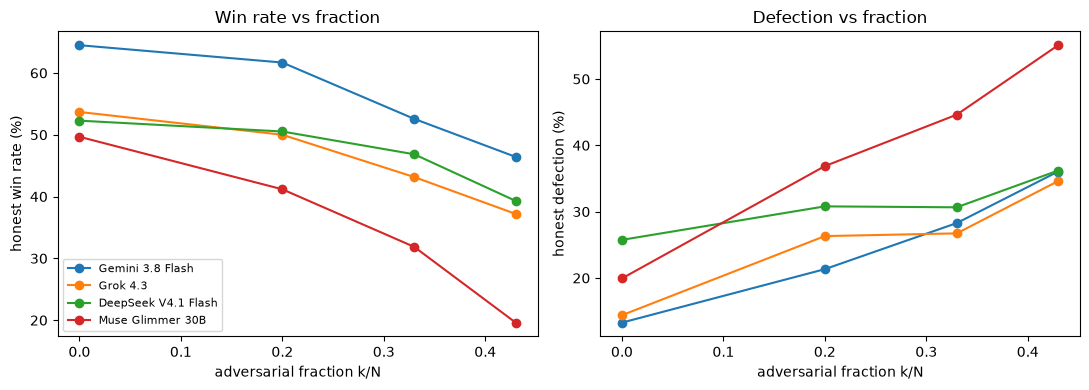

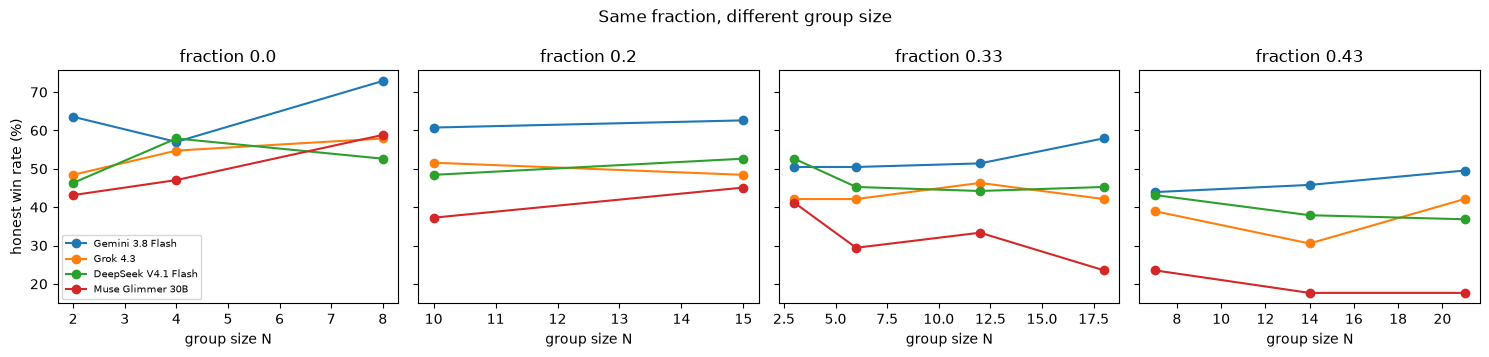

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for n, d in data.items():
    s = by_ratio(d); axes[0].plot(s.ratio, s.win, marker="o", label=n); axes[1].plot(s.ratio, s.defection, marker="o", label=n)
axes[0].set(xlabel="adversarial fraction k/N", ylabel="honest win rate (%)", title="Win rate vs fraction"); axes[1].set(xlabel="adversarial fraction k/N", ylabel="honest defection (%)", title="Defection vs fraction")
axes[0].legend(fontsize=8); plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, (r, _) in zip(axes, RATIOS):
    for n, d in data.items():
        s = d[np.isclose(d.ratio, r)].groupby("N").win.mean()*100; ax.plot(s.index, s.values, marker="o", label=n)
    ax.set(title=f"fraction {r}", xlabel="group size N")
axes[0].set_ylabel("honest win rate (%)"); axes[0].legend(fontsize=7); plt.suptitle("Same fraction, different group size"); plt.tight_layout(); plt.show()